In [137]:
import numpy as np
import textwrap
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import textwrap

In [150]:
ci_constant = 1.96

In [36]:
file_path = '/home/annierosen16/master_1979_2025.pkl'

with open(file_path, 'rb') as f:
    
    master = pickle.load(f)
    
master["date"] = pd.to_datetime(master["date"])

In [87]:
dry_unique_dates = master.loc[master["dryape"] == True, "date"].dt.normalize().unique()

n_dry_unique = len(dry_unique_dates)

# Wet APE unique dates

wet_unique_dates = master.loc[master["wetape"] == True, "date"].dt.normalize().unique()

n_wet_unique = len(wet_unique_dates)

print(f"Unique dry APE dates: {n_dry_unique}")

print(f"Unique wet APE dates: {n_wet_unique}")

dryapes = master[master['dryape']==True]

wetapes = master[master['wetape']==True]

Unique dry APE dates: 6070
Unique wet APE dates: 5335


In [38]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

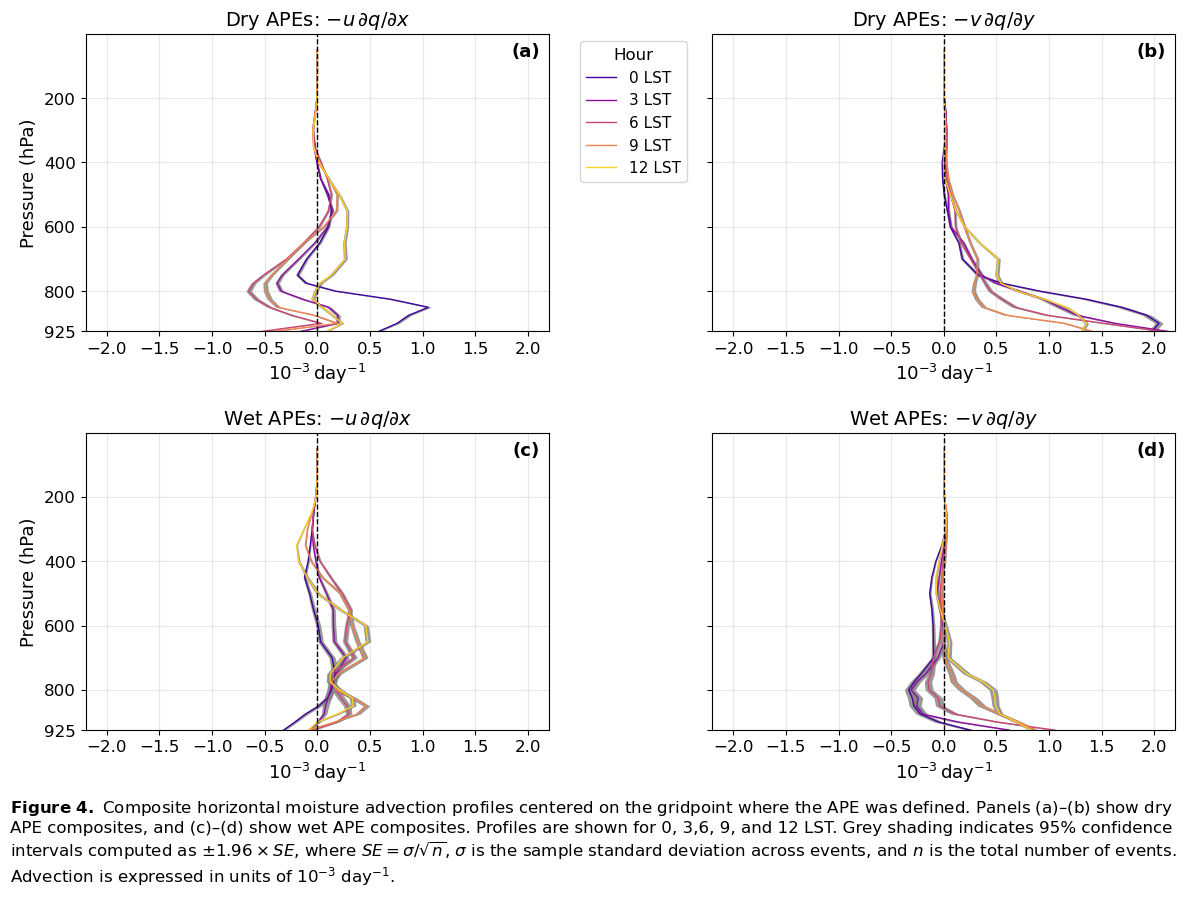

In [181]:
# ---------------------------------------------------
# Load data (matches saved payload structure)
# ---------------------------------------------------

folder = Path.home() / "advection_profiles_single_gridpoint_1979_2025"

hours = [0, 3, 6, 9, 12]

# hours = [0, 3, 6, 9, 12, 15, 18, 21]

zonal_advection_data = {}

meridional_advection_data = {}

meta_by_hr = {}

pressure = None  # read from first file (Pa -> hPa)

for hr in hours:
    
    fp = folder / f"{hr}lst_advection_profile.pkl"
    
    with open(fp, "rb") as f:
        
        data = pickle.load(f)

    zonal_advection_data[hr] = data["zonal"]         # {"mean":{...},"std":{...}}
    
    meridional_advection_data[hr] = data["meridional"]
    
    meta_by_hr[hr] = data["meta"]

    if pressure is None:
        
        pressure = np.array(data["meta"]["pressure_pa"]) / 100.0  # hPa

# mask in hPa
pressure_mask = pressure <= 925

pressure_masked = pressure[pressure_mask]

# ---------------------------------------------------
# Plot setup
# ---------------------------------------------------
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    r"Dry APEs: $-u \, \partial q / \partial x$",
    r"Dry APEs: $-v \, \partial q / \partial y$",
    r"Wet APEs: $-u \, \partial q / \partial x$",
    r"Wet APEs: $-v \, \partial q / \partial y$"
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# Shading settings
alpha_se = 0.8

# ---------------------------------------------------
# Plot profiles + SE shading
# ---------------------------------------------------
for i, hr in enumerate(hours):
    
    color = colors[i]

    # Effective sample sizes (unique events contributing to mean)
    n_dry = meta_by_hr[hr]["n_samples"]["dry"]
    
    n_wet = meta_by_hr[hr]["n_samples"]["wet"]
    
    # Effective sample sizes (unique events contributing to mean)
#     n_dry = n_dry_unique
#     n_wet = n_wet_unique

    # Means (1/day) -> scale to 1e-3 day^-1 for plotting
    zon_dry = (np.array(zonal_advection_data[hr]["mean"]["dry"]) * 1000.0)[pressure_mask]
    
    mer_dry = (np.array(meridional_advection_data[hr]["mean"]["dry"]) * 1000.0)[pressure_mask]
    
    zon_wet = (np.array(zonal_advection_data[hr]["mean"]["wet"]) * 1000.0)[pressure_mask]
    
    mer_wet = (np.array(meridional_advection_data[hr]["mean"]["wet"]) * 1000.0)[pressure_mask]

    # Std dev (1/day) -> scale to 1e-3 day^-1
    
    zon_std_dry = (np.array(zonal_advection_data[hr]["std"]["dry"]) * 1000.0)[pressure_mask]
    
    mer_std_dry = (np.array(meridional_advection_data[hr]["std"]["dry"]) * 1000.0)[pressure_mask]
    
    zon_std_wet = (np.array(zonal_advection_data[hr]["std"]["wet"]) * 1000.0)[pressure_mask]
    
    mer_std_wet = (np.array(meridional_advection_data[hr]["std"]["wet"]) * 1000.0)[pressure_mask]

    # Standard error = std / sqrt(n); guard against n=0/1
    
    se_zon_dry = zon_std_dry / np.sqrt(n_dry) if n_dry and n_dry > 1 else np.full_like(zon_dry, np.nan)
    
    se_mer_dry = mer_std_dry / np.sqrt(n_dry) if n_dry and n_dry > 1 else np.full_like(mer_dry, np.nan)
    
    se_zon_wet = zon_std_wet / np.sqrt(n_wet) if n_wet and n_wet > 1 else np.full_like(zon_wet, np.nan)
    
    se_mer_wet = mer_std_wet / np.sqrt(n_wet) if n_wet and n_wet > 1 else np.full_like(mer_wet, np.nan)
        
    # --- plot lines
    
    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST", linewidth=1.0)
    
    axs[1].plot(mer_dry, pressure_masked, color=color, linewidth=1.0)
    
    axs[2].plot(zon_wet, pressure_masked, color=color, linewidth=1.0)
    
    axs[3].plot(mer_wet, pressure_masked, color=color, linewidth=1.0)
    
#     # --- se shading (x-direction shading at each pressure level)
        
#     axs[0].fill_betweenx(pressure_masked, zon_dry - se_zon_dry, zon_dry + se_zon_dry,
#                          color='grey', alpha=alpha_se, linewidth=0)
    
#     axs[1].fill_betweenx(pressure_masked, mer_dry - se_mer_dry, mer_dry + se_mer_dry,
    
#                          color='grey', alpha=alpha_se, linewidth=0)
    
#     axs[2].fill_betweenx(pressure_masked, zon_wet - se_zon_wet, zon_wet + se_zon_wet,
                         
#                          color='grey', alpha=alpha_se, linewidth=0)
    
#     axs[3].fill_betweenx(pressure_masked, mer_wet - se_mer_wet, mer_wet + se_mer_wet,
                         
#                          color='grey', alpha=alpha_se, linewidth=0)

    # --- CI shading (x-direction shading at each pressure level)
    
    ci_constant = 1.96
    
    axs[0].fill_betweenx(pressure_masked, zon_dry - (ci_constant*se_zon_dry), zon_dry + (ci_constant*se_zon_dry),
                         color='grey', alpha=alpha_se, linewidth=0)
    
    axs[1].fill_betweenx(pressure_masked, mer_dry - (ci_constant*se_mer_dry), mer_dry + (ci_constant*se_mer_dry),
    
                         color='grey', alpha=alpha_se, linewidth=0)
    
    axs[2].fill_betweenx(pressure_masked, zon_wet - (ci_constant*se_zon_wet), zon_wet + (ci_constant*se_zon_wet),
                         
                         color='grey', alpha=alpha_se, linewidth=0)
    
    axs[3].fill_betweenx(pressure_masked, mer_wet - (ci_constant*se_mer_wet), mer_wet + (ci_constant*se_mer_wet),
                         
                         color='grey', alpha=alpha_se, linewidth=0)
    
#     # --- std shading (x-direction shading at each pressure level)
    
#     axs[0].fill_betweenx(pressure_masked, zon_dry - zon_std_dry, zon_dry + zon_std_dry,
                         
#                          color=color, alpha=alpha_se, linewidth=0)
        
#     axs[1].fill_betweenx(pressure_masked, mer_dry - mer_std_dry, mer_dry + mer_std_dry,
    
#                          color=color, alpha=alpha_se, linewidth=0)
    
#     axs[2].fill_betweenx(pressure_masked, zon_wet - zon_std_wet, zon_wet + zon_std_wet,
                         
#                          color=color, alpha=alpha_se, linewidth=0)
    
#     axs[3].fill_betweenx(pressure_masked, mer_wet - mer_std_wet, mer_wet + mer_std_wet,
                         
#                          color=color, alpha=alpha_se, linewidth=0)
    
# ---------------------------------------------------
# Style subplots
# ---------------------------------------------------

for ax, title, label in zip(axs, titles, panel_labels):

    ax.set_title(title, fontsize=14)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(925, 0)  # invert pressure properly

    yticks = [925, 800, 600, 400, 200]
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=12)

    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # Panel label (a–d)
    ax.text(
        0.98, 0.97, label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13, fontweight="bold"
    )

# Left-side y-labels
axs[0].set_ylabel("Pressure (hPa)", fontsize=13)
axs[2].set_ylabel("Pressure (hPa)", fontsize=13)

axs[0].legend(
    title="Hour",
    fontsize=11,
    title_fontsize=12,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# ---------------------------------------------------
# Title + caption
# ---------------------------------------------------
# fig.suptitle(
#     r"$\bf{Figure\ 4.}$ Horizontal Moisture Advection "
#     r"($-u \, \partial q / \partial x$, $-v \, \partial q / \partial y$)",
#     fontsize=16,
#     y=0.95
# )

caption = (
    r"$\bf{Figure\ 4.}$ "
    "Composite horizontal moisture advection profiles centered on the gridpoint "
    "where the APE was defined. Panels (a)–(b) show dry APE composites, and "
    "(c)–(d) show wet APE composites. Profiles are shown for 0, 3,6, 9, and "
    "12 LST. Grey shading indicates 95% confidence intervals computed as "
    r"$\pm 1.96 \times SE$, where $SE = \sigma/\sqrt{n}$, $\sigma$ is the sample standard deviation "
    "across events, and $n$ is the total number of events. "
    r"Advection is expressed in units of $10^{-3}$ day$^{-1}$."
)
fig.text(
    0.01, 0.02,
    
    caption,
    
    ha="left",
    
    va="bottom",
    
    fontsize=12,
    
    wrap=True
)

plt.tight_layout(rect=[0, 0.10, 1, 0.92])

plt.show()

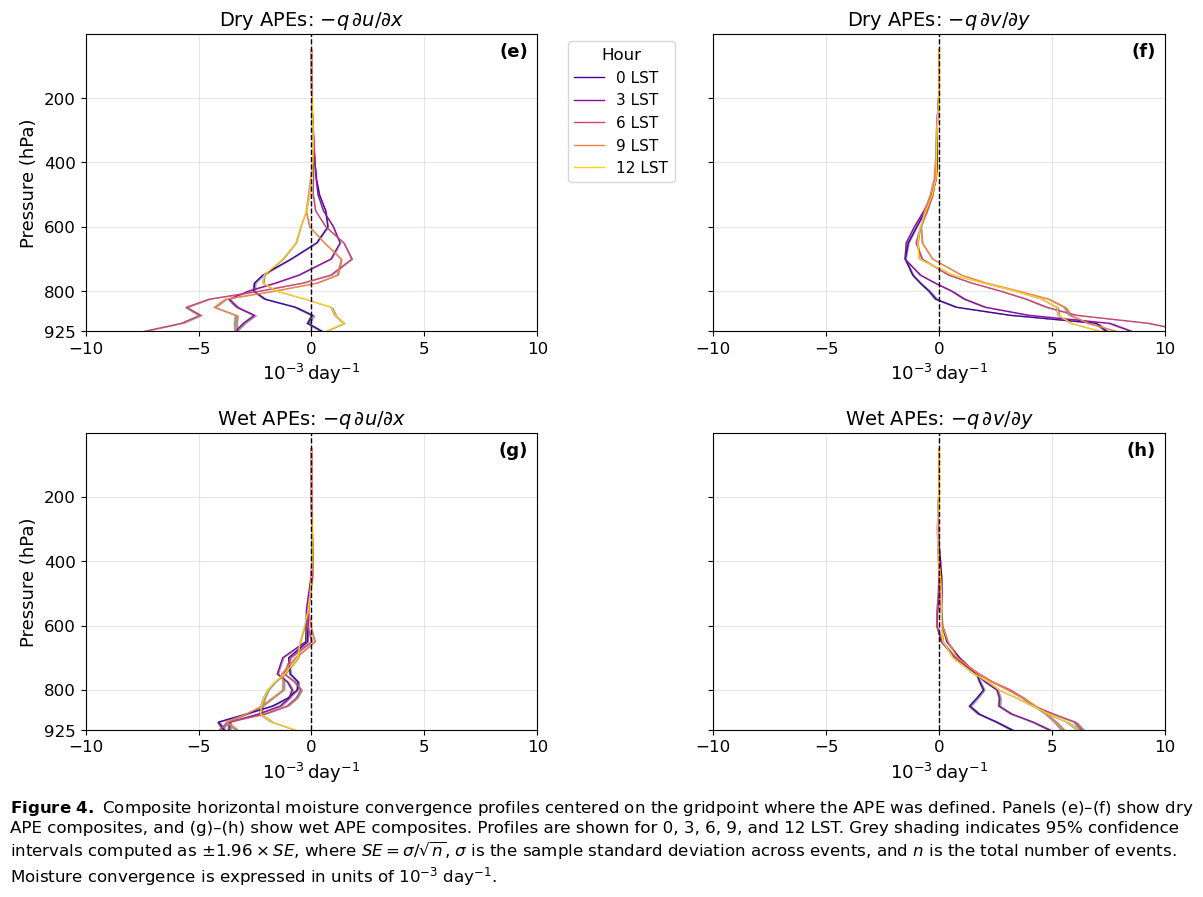

In [180]:
# ---------------------------------------------------
# Figure 5: Horizontal Moisture Convergence (matches Figure 4 format)
# Reads new payload structure correctly (mean/std + meta pressure + n_samples)
# ---------------------------------------------------

# ---------------------------------------------------
# Load data (matches saved payload structure)
# ---------------------------------------------------
folder = Path.home() / "convergence_profiles_single_gridpoint_1979_2025"

hours = [0, 3, 6, 9, 12]

# hours = [0, 3, 6, 9, 12, 15, 18, 21]

zonal_convergence_data = {}

meridional_convergence_data = {}

meta_by_hr = {}

pressure = None  # hPa from meta

for hr in hours:
    fp = folder / f"{hr}lst_convergence_profile.pkl"
    with open(fp, "rb") as f:
        data = pickle.load(f)

    # expected structure: {"mean": {"dry","wet"}, "std": {"dry","wet"}}
    zonal_convergence_data[hr] = data["zonal"]
    meridional_convergence_data[hr] = data["meridional"]
    meta_by_hr[hr] = data["meta"]

    if pressure is None:
        pressure = np.array(data["meta"]["pressure_pa"]) / 100.0  # Pa -> hPa

# mask in hPa
pressure_mask = pressure <= 925
pressure_masked = pressure[pressure_mask]

# ---------------------------------------------------
# Plot setup
# ---------------------------------------------------
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(hours)))

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axs = axs.flatten()

titles = [
    r"Dry APEs: $-q \, \partial u / \partial x$",
    r"Dry APEs: $-q \, \partial v / \partial y$",
    r"Wet APEs: $-q \, \partial u / \partial x$",
    r"Wet APEs: $-q \, \partial v / \partial y$",
]
panel_labels = ["(e)", "(f)", "(g)", "(h)"]

# Shading settings (match your Fig 4 script)
alpha_se = 0.8

# ---------------------------------------------------
# Plot profiles + SE shading
# ---------------------------------------------------
for i, hr in enumerate(hours):
    color = colors[i]

    # Effective sample sizes (unique events contributing to mean)
    n_dry = meta_by_hr[hr]["n_samples"]["dry"]
    n_wet = meta_by_hr[hr]["n_samples"]["wet"]

    # Means (1/day) -> scale to 1e-3 day^-1 for plotting
    zon_dry = (np.array(zonal_convergence_data[hr]["mean"]["dry"]) * 1000.0)[pressure_mask]
    mer_dry = (np.array(meridional_convergence_data[hr]["mean"]["dry"]) * 1000.0)[pressure_mask]
    zon_wet = (np.array(zonal_convergence_data[hr]["mean"]["wet"]) * 1000.0)[pressure_mask]
    mer_wet = (np.array(meridional_convergence_data[hr]["mean"]["wet"]) * 1000.0)[pressure_mask]

    # Std dev (1/day) -> scale to 1e-3 day^-1
    zon_std_dry = (np.array(zonal_convergence_data[hr]["std"]["dry"]) * 1000.0)[pressure_mask]
    mer_std_dry = (np.array(meridional_convergence_data[hr]["std"]["dry"]) * 1000.0)[pressure_mask]
    zon_std_wet = (np.array(zonal_convergence_data[hr]["std"]["wet"]) * 1000.0)[pressure_mask]
    mer_std_wet = (np.array(meridional_convergence_data[hr]["std"]["wet"]) * 1000.0)[pressure_mask]

    # Standard error = std / sqrt(n); guard against n=0/1
    se_zon_dry = zon_std_dry / np.sqrt(n_dry) if n_dry and n_dry > 1 else np.full_like(zon_dry, np.nan)
    se_mer_dry = mer_std_dry / np.sqrt(n_dry) if n_dry and n_dry > 1 else np.full_like(mer_dry, np.nan)
    se_zon_wet = zon_std_wet / np.sqrt(n_wet) if n_wet and n_wet > 1 else np.full_like(zon_wet, np.nan)
    se_mer_wet = mer_std_wet / np.sqrt(n_wet) if n_wet and n_wet > 1 else np.full_like(mer_wet, np.nan)
    
    # --- plot lines
    axs[0].plot(zon_dry, pressure_masked, color=color, label=f"{hr} LST", linewidth=1.0)
    axs[1].plot(mer_dry, pressure_masked, color=color, linewidth=1.0)
    axs[2].plot(zon_wet, pressure_masked, color=color, linewidth=1.0)
    axs[3].plot(mer_wet, pressure_masked, color=color, linewidth=1.0)

#     # --- SE shading (x-direction shading at each pressure level)
#     axs[0].fill_betweenx(pressure_masked, zon_dry - se_zon_dry, zon_dry + se_zon_dry,
#                          color=color, alpha=alpha_se, linewidth=0)
#     axs[1].fill_betweenx(pressure_masked, mer_dry - se_mer_dry, mer_dry + se_mer_dry,
#                          color=color, alpha=alpha_se, linewidth=0)
#     axs[2].fill_betweenx(pressure_masked, zon_wet - se_zon_wet, zon_wet + se_zon_wet,
#                          color=color, alpha=alpha_se, linewidth=0)
#     axs[3].fill_betweenx(pressure_masked, mer_wet - se_mer_wet, mer_wet + se_mer_wet,
#                          color=color, alpha=alpha_se, linewidth=0)

    # --- CI shading (x-direction shading at each pressure level)
    
    ci_constant = 1.96
    
    axs[0].fill_betweenx(pressure_masked, zon_dry - (ci_constant*se_zon_dry), zon_dry + (ci_constant*se_zon_dry),
                         color='grey', alpha=alpha_se, linewidth=0)
    axs[1].fill_betweenx(pressure_masked, mer_dry - (ci_constant*se_mer_dry), mer_dry + (ci_constant*se_mer_dry),
                         color='grey', alpha=alpha_se, linewidth=0)
    axs[2].fill_betweenx(pressure_masked, zon_wet - (ci_constant*se_zon_wet), zon_wet + (ci_constant*se_zon_wet),
                         color='grey', alpha=alpha_se, linewidth=0)
    axs[3].fill_betweenx(pressure_masked, mer_wet - (ci_constant*se_mer_wet), mer_wet + (ci_constant*se_mer_wet),
                         color='grey', alpha=alpha_se, linewidth=0)


# ---------------------------------------------------
# Style subplots (match Fig 4 formatting)
# ---------------------------------------------------
for ax, title, label in zip(axs, titles, panel_labels):

    ax.set_title(title, fontsize=14)
    ax.set_xticks(np.arange(-10, 11, 5))
    ax.set_xlim(-10, 10)       # convergence range (from your old script)
    ax.set_ylim(925, 0)        # invert pressure properly

    yticks = [925, 800, 600, 400, 200]
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(int(p)) for p in yticks], fontsize=12)

    ax.set_xlabel(r"$10^{-3} \, \mathrm{day}^{-1}$", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1)

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # Panel label (a–d)
    ax.text(
        0.98, 0.97, label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13, fontweight="bold"
    )

# Left-side y-labels
axs[0].set_ylabel("Pressure (hPa)", fontsize=13)
axs[2].set_ylabel("Pressure (hPa)", fontsize=13)

axs[0].legend(
    title="Hour",
    fontsize=11,
    title_fontsize=12,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# ---------------------------------------------------
# Title + caption (Figure 5, same style as Fig 4)
# ---------------------------------------------------
# fig.suptitle(
#     r"$\bf{Figure\ 5.}$ Horizontal Moisture Convergence "
#     r"($-u \, \partial q / \partial x$, $-v \, \partial q / \partial y$)",
#     fontsize=16,
#     y=0.95
# )

caption = (
    r"$\bf{Figure\ 4.}$ "
    "Composite horizontal moisture convergence profiles centered on the gridpoint "
    "where the APE was defined. Panels (e)–(f) show dry APE composites, and "
    "(g)–(h) show wet APE composites. Profiles are shown for 0, 3, 6, 9, and "
    "12 LST. Grey shading indicates 95% confidence intervals computed as "
    r"$\pm 1.96 \times SE$, where $SE = \sigma/\sqrt{n}$, $\sigma$ is the sample standard deviation "
    "across events, and $n$ is the total number of events. "
    r"Moisture convergence is expressed in units of $10^{-3}$ day$^{-1}$."
)

fig.text(
    0.01, 0.02,
    caption,
    ha="left",
    va="bottom",
    fontsize=12,
    wrap=True
)

plt.tight_layout(rect=[0, 0.10, 1, 0.92])

plt.show()

### loading surface terms

In [126]:
# Load the pickle file

with open('/home/annierosen16/diurnal_sfc_term_1979_2025.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_sfc_term_dry = data['dry'] * 1000

diurnal_sfc_term_wet = data['wet'] * 1000

# Load the pickle file

with open('/home/annierosen16/diurnal_sfc_term_1979_2025_std.pkl', 'rb') as f:
    
    data = pickle.load(f)

diurnal_sfc_term_dry_std = data['dry'] * 1000

diurnal_sfc_term_wet_std = data['wet'] * 1000

diurnal_sfc_term_dry_se = diurnal_sfc_term_dry_std / np.sqrt(dryapes.shape[0])

diurnal_sfc_term_wet_se = diurnal_sfc_term_wet_std / np.sqrt(wetapes.shape[0])

### loading ET

In [90]:
with open('/home/annierosen16/et_composites_1979_2025.pkl', 'rb') as f:
    
    diurnal_et = pickle.load(f)
    
    diurnal_et_dry = diurnal_et['dry']
    
    diurnal_et_wet = diurnal_et['wet']
    
with open('/home/annierosen16/et_composites_1979_2025_std.pkl', 'rb') as f:
    
    diurnal_et_std = pickle.load(f)
    
    diurnal_et_dry_std = diurnal_et_std['dry']
    
    diurnal_et_wet_std = diurnal_et_std['wet']
    
diurnal_et_dry_se = diurnal_et_dry_std / np.sqrt(dryapes.shape[0])

diurnal_et_wet_se = diurnal_et_wet_std / np.sqrt(wetapes.shape[0])

### loading precip

In [43]:
dry_case = master[master['dryape']==True]

wet_case = master[master['wetape']==True]

hr_to_day = 24

# stack daily_precip arrays and compute the hourly average

diurnal_precip_dry = np.vstack(dry_case['daily_precip'].values).mean(axis=0) * hr_to_day

diurnal_precip_wet = np.vstack(wet_case['daily_precip'].values).mean(axis=0) * hr_to_day

diurnal_precip_dry_std = np.vstack(dry_case['daily_precip'].values).std(axis=0, ddof=1) * hr_to_day

diurnal_precip_wet_std = np.vstack(wet_case['daily_precip'].values).std(axis=0, ddof=1) * hr_to_day

diurnal_precip_dry_se = diurnal_precip_dry_std / np.sqrt(dry_case.shape[0])

diurnal_precip_wet_se = diurnal_precip_wet_std / np.sqrt(wet_case.shape[0])

### loading vertical flux diff (qw_800 hpa - qw_600 hpa)

In [44]:
file_path = "/home/annierosen16/lt_diurnal_vertical_flux_diff_1979_2025.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

lt_diurnal_vertical_flux_dry = data["dryapes_mean_diurnal_vertical_flux_diff"]

lt_diurnal_vertical_flux_wet = data["wetapes_mean_diurnal_vertical_flux_diff"]

### loading qw800 & qw600

In [144]:
file_path = "/home/annierosen16/_800qw_1979_2025.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

_800qw_dry = data["_800qw_dryapes"]

_800qw_wet = data["_800qw_wetapes"]

## load std below

file_path = "/home/annierosen16/_800qw_1979_2025_std.pkl"

with open(file_path, "rb") as f:
    
    data_std = pickle.load(f)

_800qw_dry_std = data_std["_800qw_dryapes_std"]

_800qw_wet_std = data_std["_800qw_wetapesdt"]

_800_dry_ci = ci_constant*(_800qw_dry_std / np.sqrt(dryapes.shape[0]))

_800_wet_ci = ci_constant*(_800qw_wet_std / np.sqrt(wetapes.shape[0]))

In [145]:
file_path = "/home/annierosen16/_600qw_1979_2025.pkl"

with open(file_path, "rb") as f:
    
    data = pickle.load(f)

_600qw_dry = data["_600qw_dryapes"]

_600qw_wet = data["_600qw_wetapes"]

## waiting on these to complete, load std below

file_path = "/home/annierosen16/_600qw_1979_2025_std.pkl"

with open(file_path, "rb") as f:
    
    data_std = pickle.load(f)

_600qw_dry_std = data_std["_600qw_dryapes_std"]

_600qw_wet_std = data_std["_600qw_wetapes_std"]

_600_dry_ci = ci_constant*(_600qw_dry_std / np.sqrt(dryapes.shape[0]))

_600_wet_ci = ci_constant*(_600qw_wet_std / np.sqrt(wetapes.shape[0]))

### uploading separate of BL and LT time tendency 

In [153]:
with open('/home/annierosen16/bl_diurnal_time_tendency_1979_2025.pkl', 'rb') as f:
    
    bl_data = pickle.load(f)

bl_diurnal_time_tendency_dry = list(bl_data['dry'])

bl_diurnal_time_tendency_wet = list(bl_data['wet'])

with open('/home/annierosen16/lt_diurnal_time_tendency_1979_2025.pkl', 'rb') as f:
    
    lt_data = pickle.load(f)

lt_diurnal_time_tendency_dry = list(lt_data['dry'])

lt_diurnal_time_tendency_wet = list(lt_data['wet'])

## load standard deviation 

with open('/home/annierosen16/bl_diurnal_time_tendency_std_1979_2025.pkl', 'rb') as f:
    
    bl_data_std = pickle.load(f)

bl_diurnal_time_tendency_dry_std = list(bl_data_std['dry'])

bl_diurnal_time_tendency_wet_std = list(bl_data_std['wet'])

bl_diurnal_time_tendency_dry_ci = ci_constant*(bl_diurnal_time_tendency_dry_std / np.sqrt(dryapes.shape[0]))

bl_diurnal_time_tendency_wet_ci = ci_constant*(bl_diurnal_time_tendency_wet_std / np.sqrt(wetapes.shape[0]))

with open('/home/annierosen16/lt_diurnal_time_tendency_std_1979_2025.pkl', 'rb') as f:
    
    lt_data_std = pickle.load(f)

lt_diurnal_time_tendency_dry_std = list(lt_data_std['dry'])

lt_diurnal_time_tendency_wet_std = list(lt_data_std['wet'])

lt_diurnal_time_tendency_dry_ci = ci_constant*(lt_diurnal_time_tendency_dry_std / np.sqrt(dryapes.shape[0]))

lt_diurnal_time_tendency_wet_ci = ci_constant*(lt_diurnal_time_tendency_wet_std / np.sqrt(wetapes.shape[0]))

### separating horizontal advection & convergence into BL and LT layers

In [48]:
def apply_pressure_mask(nested_dict, pressure_mask):

    masked_dict = {}

    for outer_key, inner_dict in nested_dict.items():
        
        masked_dict[outer_key] = {}
        
        for inner_key, array in inner_dict.items():
            
            masked_dict[outer_key][inner_key] = array[pressure_mask]
    
    return masked_dict

In [49]:
bl_pressure_mask = (pressure >= 800) & (pressure <= 925)

lt_pressure_mask = (pressure >= 600) & (pressure < 800)

bl_pressure_masked = pressure[bl_pressure_mask]

lt_pressure_masked = pressure[lt_pressure_mask]

In [50]:
def flatten_to_means(nested_dict):
    """
    Convert:
      {t: {'mean': {'dry': arr, 'wet': arr}, 'std': {...}}}
    to:
      {t: {'dry': arr, 'wet': arr}}
    """
    flat = {}
    for t, d in nested_dict.items():
        
        flat[t] = {
            
            'dry': d['mean']['dry'],
            
            'wet': d['mean']['wet'],
}
    return flat

zonal_advection_mean = flatten_to_means(zonal_advection_data)

zonal_convergence_mean = flatten_to_means(zonal_convergence_data)

meridional_advection_mean = flatten_to_means(meridional_advection_data)

meridional_convergence_mean = flatten_to_means(meridional_convergence_data)

In [51]:
def flatten_to_std(nested_dict):
    """
    Convert:
      {t: {'mean': {'dry': arr, 'wet': arr}, 'std': {...}}}
    to:
      {t: {'dry': arr, 'wet': arr}}
    """
    flat = {}
    
    for t, d in nested_dict.items():
        
        flat[t] = {
            
            'dry': d['std']['dry'],
            
            'wet': d['std']['wet'],
}
    return flat

zonal_advection_std = flatten_to_std(zonal_advection_data)

zonal_convergence_std = flatten_to_std(zonal_convergence_data)

meridional_advection_std = flatten_to_std(meridional_advection_data)

meridional_convergence_std = flatten_to_std(meridional_convergence_data)

In [52]:
# masking for BL

bl_zonal_advection_mean = apply_pressure_mask(zonal_advection_mean, bl_pressure_mask)

bl_zonal_convergence_mean = apply_pressure_mask(zonal_convergence_mean, bl_pressure_mask)

bl_meridional_advection_mean = apply_pressure_mask(meridional_advection_mean, bl_pressure_mask)

bl_meridional_convergence_mean = apply_pressure_mask(meridional_convergence_mean, bl_pressure_mask)

# masking for LT

lt_zonal_advection_mean = apply_pressure_mask(zonal_advection_mean, lt_pressure_mask)

lt_zonal_convergence_mean = apply_pressure_mask(zonal_convergence_mean, lt_pressure_mask)

lt_meridional_advection_mean = apply_pressure_mask(meridional_advection_mean, lt_pressure_mask)

lt_meridional_convergence_mean = apply_pressure_mask(meridional_convergence_mean, lt_pressure_mask)

In [53]:
# masking for BL

bl_zonal_advection_std = apply_pressure_mask(zonal_advection_std, bl_pressure_mask)

bl_zonal_convergence_std = apply_pressure_mask(zonal_convergence_std, bl_pressure_mask)

bl_meridional_advection_std = apply_pressure_mask(meridional_advection_std, bl_pressure_mask)

bl_meridional_convergence_std = apply_pressure_mask(meridional_convergence_std, bl_pressure_mask)

# masking for LT

lt_zonal_advection_std = apply_pressure_mask(zonal_advection_std, lt_pressure_mask)

lt_zonal_convergence_std = apply_pressure_mask(zonal_convergence_std, lt_pressure_mask)

lt_meridional_advection_std = apply_pressure_mask(meridional_advection_std, lt_pressure_mask)

lt_meridional_convergence_std = apply_pressure_mask(meridional_convergence_std, lt_pressure_mask)

In [54]:
## vertically integrate horizontal convergence & advection

def vertically_integrated_profile_in_pressure(profile, levels):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    m_to_mm = 1000
                    
    dp = np.diff(levels)
            
    integrated_value = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * m_to_mm

    return integrated_value

def integrate_profiles(data, pressure, unit_adjustment=1000, apply_unit_adjustment=True):
    
    pressure_for_integration = pressure * 100 # conversion to Pa
        
    integrated_profiles = {}

    for time, label_dict in data.items():
        
        integrated_profiles[time] = {}
        
        for label, profile in label_dict.items():
            
            if apply_unit_adjustment:
                
                profile = profile / unit_adjustment
            
            integrated_profiles[time][label] = vertically_integrated_profile_in_pressure(profile, pressure_for_integration)
    
    return integrated_profiles

### integrating function for std of advection and convergence profiles

In [55]:
def vertically_integrated_std_in_pressure(std_profile, levels):
    
    g = 9.81
    
    rho_water = 1000
    
    m_to_mm = 1000
    
    dp = np.diff(levels)
    
    # trapezoidal weights for each level (same as in the mean integration)
    
    weights = 0.5 * dp  # shape: (n_levels - 1,)
    
    # each interior level contributes to two intervals, so accumulate weights
    w = np.zeros_like(std_profile)
    
    w[:-1] += weights
    
    w[1:]  += weights
    
    # scale weights by the same constants as the mean
    
    w = w / (g * rho_water) * m_to_mm
    
    # propagate std: sigma_Q = sqrt(sum(w_i^2 * sigma_i^2))
    
    integrated_std = np.sqrt(np.sum((w * std_profile) ** 2))
    
    return integrated_std


def integrate_std_profiles(std_data, pressure, unit_adjustment=1000, apply_unit_adjustment=True):
    
    pressure_for_integration = pressure * 100  # hPa to Pa
    
    integrated_stds = {}
    
    for time, label_dict in std_data.items():
        
        integrated_stds[time] = {}
        
        for label, std_profile in label_dict.items():
            
            if apply_unit_adjustment:
                
                std_profile = std_profile / unit_adjustment
            
            integrated_stds[time][label] = vertically_integrated_std_in_pressure(std_profile, pressure_for_integration)
    
    return integrated_stds

### integrating for BL

In [56]:
bl_integrated_zonal_advection_profiles = integrate_profiles(bl_zonal_advection_mean, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_advection_profiles = integrate_profiles(bl_meridional_advection_mean, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_zonal_convergence_profiles = integrate_profiles(bl_zonal_convergence_mean, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_convergence_profiles = integrate_profiles(bl_meridional_convergence_mean, bl_pressure_masked, apply_unit_adjustment=False)

### integrating for LT

In [57]:
lt_integrated_zonal_advection_profiles = integrate_profiles(lt_zonal_advection_mean, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_advection_profiles = integrate_profiles(lt_meridional_advection_mean, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_zonal_convergence_profiles = integrate_profiles(lt_zonal_convergence_mean, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_convergence_profiles = integrate_profiles(lt_meridional_convergence_mean, lt_pressure_masked, apply_unit_adjustment=False)

### integrating std for BL 

In [58]:
bl_integrated_zonal_advection_std = integrate_std_profiles(bl_zonal_advection_std, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_advection_std = integrate_std_profiles(bl_meridional_advection_std, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_zonal_convergence_std = integrate_std_profiles(bl_zonal_convergence_std, bl_pressure_masked, apply_unit_adjustment=False)

bl_integrated_meridional_convergence_std = integrate_std_profiles(bl_meridional_convergence_std, bl_pressure_masked, apply_unit_adjustment=False)

### integrating std for LT

In [59]:
lt_integrated_zonal_advection_std = integrate_std_profiles(lt_zonal_advection_std, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_advection_std = integrate_std_profiles(lt_meridional_advection_std, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_zonal_convergence_std = integrate_std_profiles(lt_zonal_convergence_std, lt_pressure_masked, apply_unit_adjustment=False)

lt_integrated_meridional_convergence_std = integrate_std_profiles(lt_meridional_convergence_std, lt_pressure_masked, apply_unit_adjustment=False)

### extract diurnal cycles from arrays

In [60]:
def extract_diurnal_cycles(data_dict):
    
    """
    
    data_dict: {hour: {'dry': scalar, 'wet': scalar}}
    
    Returns hours sorted, and dry/wet arrays in that order.
    
    """
    
    sorted_hours = sorted(data_dict.keys())
    
    dry_values = np.array([data_dict[hour]['dry'] for hour in sorted_hours])
    
    wet_values = np.array([data_dict[hour]['wet'] for hour in sorted_hours])
    
    return sorted_hours, dry_values, wet_values

In [61]:
hours_zonal_adv, bl_diurnal_zonal_advection_dry, bl_diurnal_zonal_advection_wet = extract_diurnal_cycles(bl_integrated_zonal_advection_profiles)

hours_merid_adv, bl_diurnal_meridional_advection_dry, bl_diurnal_meridional_advection_wet = extract_diurnal_cycles(bl_integrated_meridional_advection_profiles)

hours_zonal_conv, bl_diurnal_zonal_convergence_dry, bl_diurnal_zonal_convergence_wet = extract_diurnal_cycles(bl_integrated_zonal_convergence_profiles)

hours_merid_conv, bl_diurnal_meridional_convergence_dry, bl_diurnal_meridional_convergence_wet = extract_diurnal_cycles(bl_integrated_meridional_convergence_profiles)

In [62]:
hours_zonal_adv, lt_diurnal_zonal_advection_dry, lt_diurnal_zonal_advection_wet = extract_diurnal_cycles(lt_integrated_zonal_advection_profiles)

hours_merid_adv, lt_diurnal_meridional_advection_dry, lt_diurnal_meridional_advection_wet = extract_diurnal_cycles(lt_integrated_meridional_advection_profiles)

hours_zonal_conv, lt_diurnal_zonal_convergence_dry, lt_diurnal_zonal_convergence_wet = extract_diurnal_cycles(lt_integrated_zonal_convergence_profiles)

hours_merid_conv, lt_diurnal_meridional_convergence_dry, lt_diurnal_meridional_convergence_wet = extract_diurnal_cycles(lt_integrated_meridional_convergence_profiles)

In [98]:
## extract diurnal cycles for BL std also 

hours_zonal_adv, bl_diurnal_zonal_advection_dry_std, bl_diurnal_zonal_advection_wet_std = extract_diurnal_cycles(bl_integrated_zonal_advection_std)

hours_merid_adv, bl_diurnal_meridional_advection_dry_std, bl_diurnal_meridional_advection_wet_std = extract_diurnal_cycles(bl_integrated_meridional_advection_std)

hours_zonal_conv, bl_diurnal_zonal_convergence_dry_std, bl_diurnal_zonal_convergence_wet_std = extract_diurnal_cycles(bl_integrated_zonal_convergence_std)

hours_merid_conv, bl_diurnal_meridional_convergence_dry_std, bl_diurnal_meridional_convergence_wet_std = extract_diurnal_cycles(bl_integrated_meridional_convergence_std)

In [103]:
## extract diurnal cycles for LT std also 

hours_zonal_adv, lt_diurnal_zonal_advection_dry_std, lt_diurnal_zonal_advection_wet_std = extract_diurnal_cycles(lt_integrated_zonal_advection_std)

hours_merid_adv, lt_diurnal_meridional_advection_dry_std, lt_diurnal_meridional_advection_wet_std = extract_diurnal_cycles(lt_integrated_meridional_advection_std)

hours_zonal_conv, lt_diurnal_zonal_convergence_dry_std, lt_diurnal_zonal_convergence_wet_std = extract_diurnal_cycles(lt_integrated_zonal_convergence_std)

hours_merid_conv, lt_diurnal_meridional_convergence_dry_std, lt_diurnal_meridional_convergence_wet_std = extract_diurnal_cycles(lt_integrated_meridional_convergence_std)

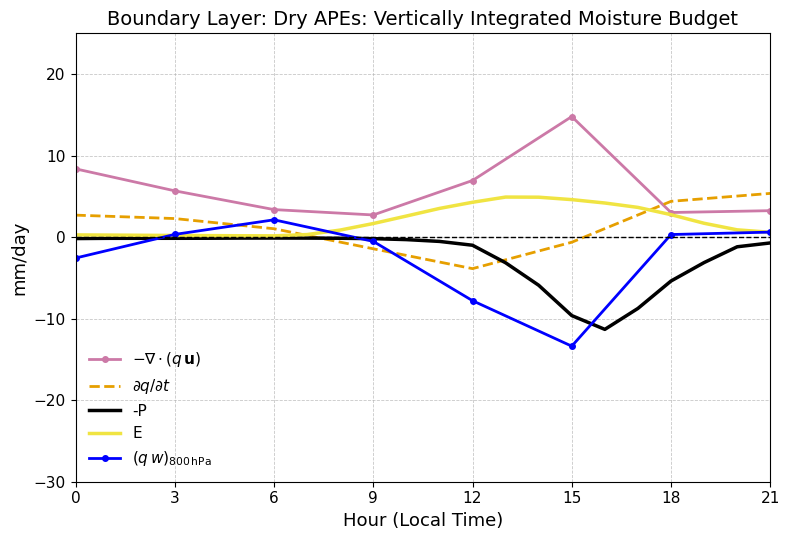

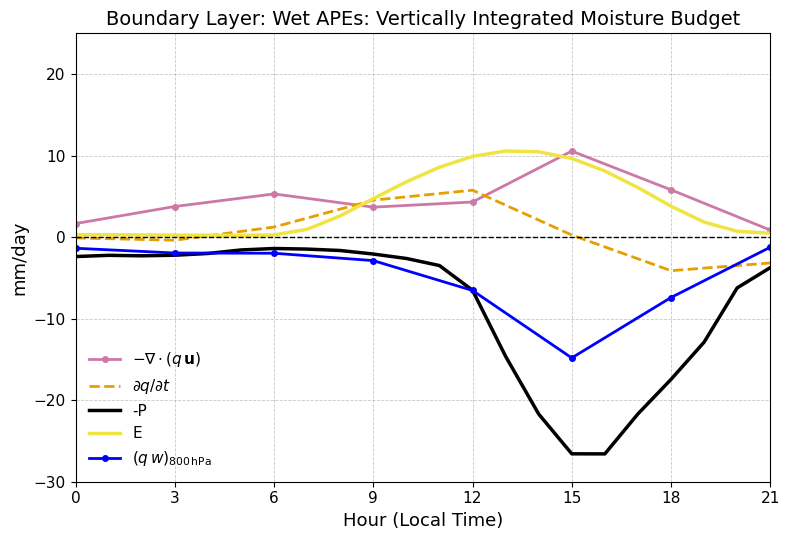

In [63]:
def plot_bl_diurnal_moisture_budget(hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv, time_tend, sfc_term, qw800, title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    mer_adv = np.array(mer_adv)
    
    zon_adv = np.array(zon_adv)
    
    mer_conv = np.array(mer_conv)
    
    zon_conv = np.array(zon_conv)
    
    time_tend = np.array(time_tend)
    
    sfc_term = np.array(sfc_term)
    
    qw800_term = np.array(qw800)*-1

    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]

    adv_total = zon_adv + mer_adv
    
    conv_total = zon_conv + mer_conv
    
    mfc_total = adv_total + conv_total + sfc_term
        
    residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term
        
    plt.figure(figsize=(8, 5.5))
    
    # Plot 3-hourly budget terms
    
#     plt.plot(hours_3hr, adv_total, label=r'$-\mathbf{u} \cdot \nabla q$', 
#          color='#D55E00', linewidth=2)          # Vermillion

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple

#     plt.plot(hours_3hr, conv_total, label=r'$-q \, \nabla \cdot \mathbf{u}$', 
#          color='#0072B2', linewidth=2)          # Blue

    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         color='#E69F00', linestyle='--', linewidth=2)  # Orange

#     plt.plot(hours_3hr, sfc_term, label='sfc', 
#          color='#009E73', linestyle='--', linewidth=2)  # Bluish green

#     plt.plot(hours_3hr, residual, label='residual', 
#          color='#56B4E9', linestyle='--', linewidth=2)  # Sky blue

    plt.plot(hours_24, precip, label='-P', 
         color='#000000', linewidth=2.5)        # Black

    plt.plot(hours_24, et, label='E', 
         color='#F0E442', linewidth=2.5)        # Yellow

    plt.plot(hours_3hr, qw800_term, label=r'$ (q\,w)_{800\,\mathrm{hPa}} $', color='blue', 
         linewidth=2, marker='o', markersize=4)
    
    # Axes and labels
    
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-30, 25)
    
    plt.show()

hours_24 = range(0,24)

# Plot for DRY APEs

plot_bl_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    bl_diurnal_meridional_advection_dry,
    
    bl_diurnal_zonal_advection_dry,
    
    bl_diurnal_meridional_convergence_dry,
    
    bl_diurnal_zonal_convergence_dry,
    
    bl_diurnal_time_tendency_dry,
    
    diurnal_sfc_term_dry, 
    
    _800qw_dry,
    
    title='Boundary Layer: Dry APEs: Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_bl_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    bl_diurnal_meridional_advection_wet,
    
    bl_diurnal_zonal_advection_wet,
    
    bl_diurnal_meridional_convergence_wet,
    
    bl_diurnal_zonal_convergence_wet,
    
    bl_diurnal_time_tendency_wet,
    
    diurnal_sfc_term_wet,
    
    _800qw_wet,
    
    title='Boundary Layer: Wet APEs: Vertically Integrated Moisture Budget')


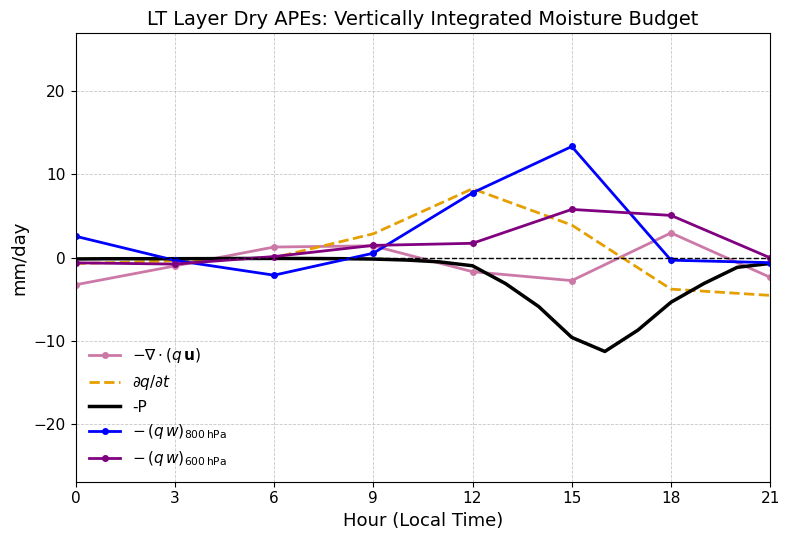

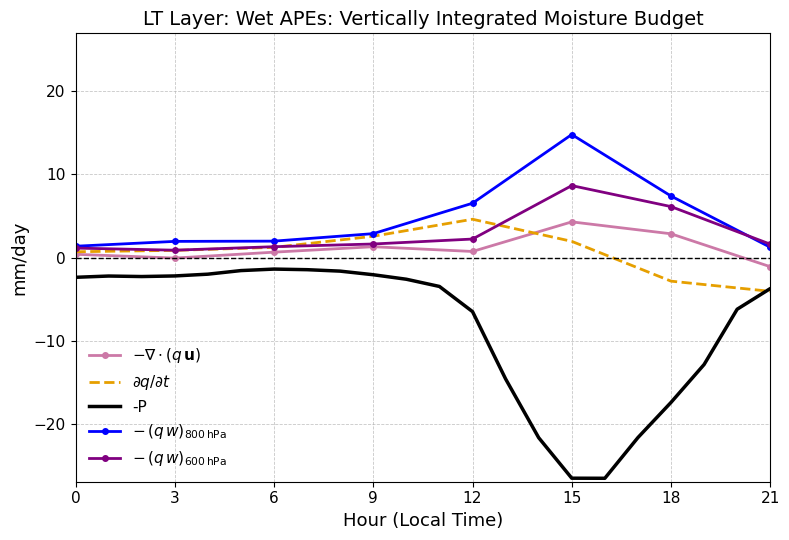

In [64]:
def plot_lt_diurnal_moisture_budget(hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv, time_tend, sfc_term, vertical_flux, qw800, qw600, title):
    
    precip = np.array(precip) * -1 # multiplication by -1 to be consistent with dq/dt = MFC - P + E form of budget
    
    et = np.array(et)
    
    mer_adv = np.array(mer_adv)
    
    zon_adv = np.array(zon_adv)
    
    mer_conv = np.array(mer_conv)
    
    zon_conv = np.array(zon_conv)
    
    time_tend = np.array(time_tend)
    
    sfc_term = np.array(sfc_term)
    
    vert_flux = np.array(vertical_flux)
    
    _800qw = np.array(qw800)
    
    _600qw = np.array(qw600)

    # Only take every 3rd element for 3-hourly fields
    
    precip_3hr = precip[::3] * -1 # multiply by -1 to reverse back to positive values for residual calculation
    
    et_3hr = et[::3]
    
    hours_3hr = hours_24[::3]

    adv_total = zon_adv + mer_adv
    
    conv_total = zon_conv + mer_conv
    
    mfc_total = adv_total + conv_total 
        
    residual = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term
        
    plt.figure(figsize=(8, 5.5))

    # Plot 3-hourly budget terms
    
#     plt.plot(hours_3hr, adv_total, label=r'$-\mathbf{u} \cdot \nabla q$', 
#          color='#D55E00', linewidth=2)          # Vermillion

    plt.plot(hours_3hr, mfc_total, label=r'$-\nabla \cdot (q \, \mathbf{u})$', 
         color='#CC79A7', linewidth=2, marker='o', markersize=4)  # Reddish purple

#     plt.plot(hours_3hr, conv_total, label=r'$-q \, \nabla \cdot \mathbf{u}$', 
#          color='#0072B2', linewidth=2)          # ltue

    plt.plot(hours_3hr, time_tend, label=r'$\partial q/\partial t$', 
         color='#E69F00', linestyle='--', linewidth=2)  # Orange

#     plt.plot(hours_3hr, sfc_term, label='sfc', 
#          color='#009E73', linestyle='--', linewidth=2)  # ltuish green

#     plt.plot(hours_3hr, residual, label='residual', 
#          color='#56B4E9', linestyle='--', linewidth=2)  # Sky ltue

    plt.plot(hours_24, precip, label='-P', 
         color='#000000', linewidth=2.5)        # black

#     plt.plot(hours_3hr, vert_flux, label=r'$-\left(q\omega_{\mathrm{in}} - q\omega_{\mathrm{out}}\right)$', color='C0', 
#              linewidth=2, marker='o', markersize=4)

    plt.plot(hours_3hr, _800qw, label=r'$-\,(q\,w)_{800\,\mathrm{hPa}}$', color='blue',
             linewidth=2, marker='o', markersize=4)

    plt.plot(hours_3hr, _600qw, label=r'$-\,(q\,w)_{600\,\mathrm{hPa}}$', color='purple',
             linewidth=2, marker='o', markersize=4)

    # Axes and labels
    
    plt.xlabel('Hour (Local Time)', fontsize=13)
    
    plt.ylabel('mm/day', fontsize=13)
    
    plt.title(title, fontsize=14)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    plt.xticks(range(0, 24, 3), fontsize=11)
    
    plt.yticks(fontsize=11)
    
    plt.xlim(0, 21)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.legend(loc='lower left', fontsize=11, frameon=False)
    
    plt.tight_layout()
    
    plt.ylim(-27, 27)
    
    plt.show()

hours_24 = range(0,24)

# Plot for DRY APEs

plot_lt_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_dry,
    
    diurnal_et_dry,
    
    lt_diurnal_meridional_advection_dry,
    
    lt_diurnal_zonal_advection_dry,
    
    lt_diurnal_meridional_convergence_dry,
    
    lt_diurnal_zonal_convergence_dry,
    
    lt_diurnal_time_tendency_dry,
    
    diurnal_sfc_term_dry, 
    
    lt_diurnal_vertical_flux_dry,
    
    _800qw_dry,
    
    _600qw_dry,
    
    title='LT Layer Dry APEs: Vertically Integrated Moisture Budget'
)

# Plot for WET APEs

plot_lt_diurnal_moisture_budget(
    
    hours_24,
    
    diurnal_precip_wet,
    
    diurnal_et_wet,
    
    lt_diurnal_meridional_advection_wet,
    
    lt_diurnal_zonal_advection_wet,
    
    lt_diurnal_meridional_convergence_wet,
    
    lt_diurnal_zonal_convergence_wet,
    
    lt_diurnal_time_tendency_wet,
    
    diurnal_sfc_term_wet,
    
    lt_diurnal_vertical_flux_wet,
    
    _800qw_wet, 
    
    _600qw_wet, 
    
    title='LT Layer: Wet APEs: Vertically Integrated Moisture Budget')


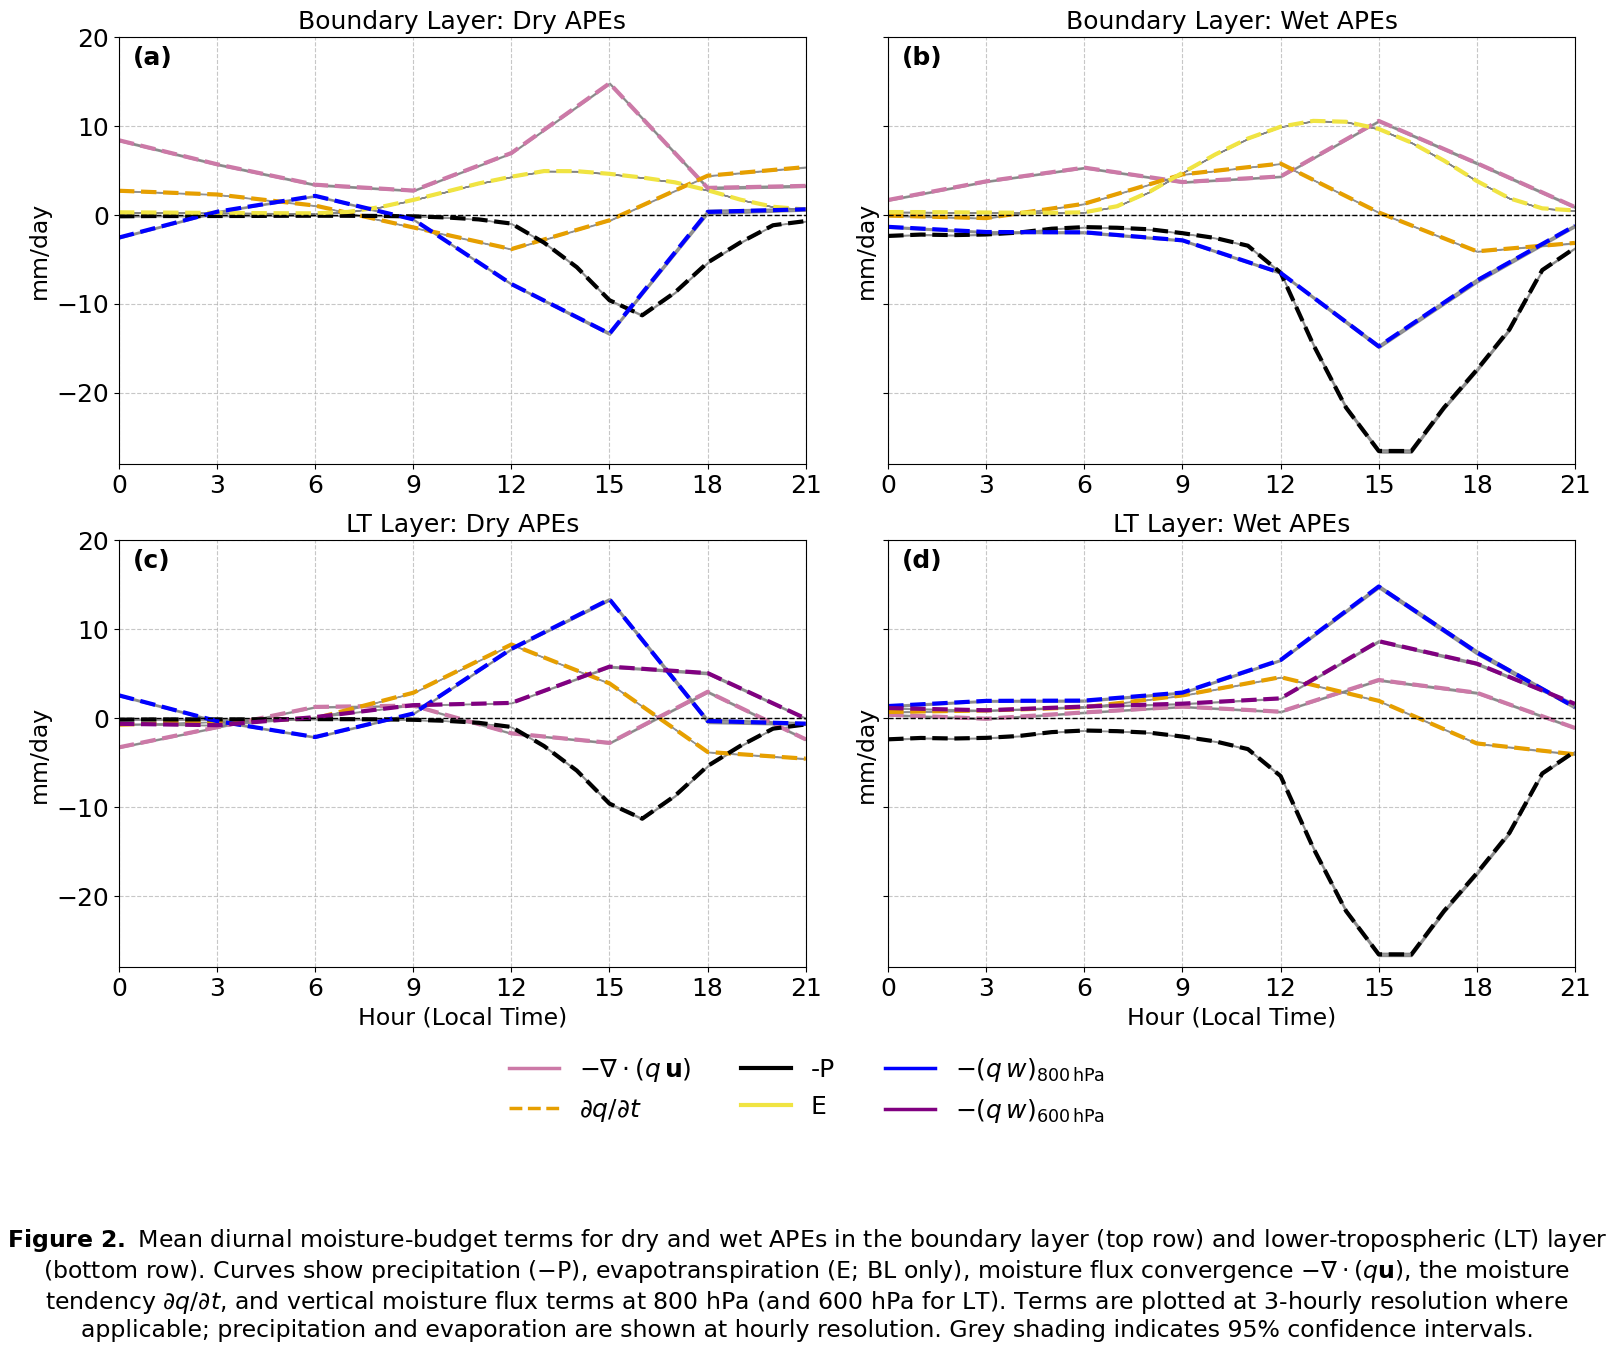

In [182]:
# ----------------------------
# Global font sizing
# ----------------------------
FS_BUMP = 4

plt.rcParams.update({
    "font.size": 11 + FS_BUMP,
    "axes.titlesize": 12 + FS_BUMP,
    "axes.labelsize": 11 + FS_BUMP,
    "xtick.labelsize": 10 + FS_BUMP,
    "ytick.labelsize": 10 + FS_BUMP,
    "legend.fontsize": 11 + FS_BUMP,
})

# ----------------------------
# 1) LT plotter -> draw on ax
# ----------------------------
def plot_lt_diurnal_moisture_budget_ax(
    ax, hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv,
    time_tend, sfc_term, vertical_flux, qw800, qw600, precip_se,
    mer_adv_std, zon_adv_std, mer_conv_std, zon_conv_std, _800_ci, _600_ci,
    time_tend_ci, 
    n_events,  # <-- moved before default args
    title,
    base_title_fs=None, base_label_fs=None, base_tick_fs=None
):
    precip    = np.array(precip) * -1
    precip_se = np.array(precip_se)
    precip_ci = 1.96 * precip_se
    et        = np.array(et)
    mer_adv   = np.array(mer_adv)
    zon_adv   = np.array(zon_adv)
    mer_conv  = np.array(mer_conv)
    zon_conv  = np.array(zon_conv)
    time_tend = np.array(time_tend)
    sfc_term  = np.array(sfc_term)
    time_tend_ci = np.array(time_tend_ci)

    mer_adv_std  = np.array(mer_adv_std)
    zon_adv_std  = np.array(zon_adv_std)
    mer_conv_std = np.array(mer_conv_std)
    zon_conv_std = np.array(zon_conv_std)


    # root-sum-of-squares for MFC uncertainty
    mfc_std = np.sqrt(mer_adv_std**2 + zon_adv_std**2 + mer_conv_std**2 + zon_conv_std**2)
    
    mfc_se = mfc_std / np.sqrt(n_events)
    
    mfc_ci = 1.96*mfc_se

    _ = np.array(vertical_flux)
    _800qw = np.array(qw800)
    _600qw = np.array(qw600)
    _800_ci = np.array(_800_ci)
    _600_ci = np.array(_600_ci)

    hours_3hr  = np.array(list(hours_24))[::3]
    precip_3hr = precip[::3] * -1
    et_3hr     = et[::3]

    adv_total  = zon_adv + mer_adv
    conv_total = zon_conv + mer_conv
    mfc_total  = adv_total + conv_total

    _ = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term

    ax.plot(hours_3hr, mfc_total,
            label=r'$-\nabla \cdot (q \, \mathbf{u})$',
            color='#CC79A7', linewidth=3, linestyle='--')
    
    ax.fill_between(hours_3hr,
                    mfc_total - mfc_ci,
                    mfc_total + mfc_ci,
                    color='grey', alpha=0.8)

    ax.plot(hours_3hr, time_tend,
            label=r'$\partial q/\partial t$',
            color='#E69F00', linestyle='--', linewidth=3)
    
    ax.fill_between(hours_3hr, time_tend - time_tend_ci, time_tend + time_tend_ci,
                   color='grey', alpha=0.8)

    ax.plot(list(hours_24), precip,
            label='-P',
            color='#000000', linewidth=3, linestyle='--')
    
    ax.fill_between(list(hours_24),
                    precip - precip_ci,
                    precip + precip_ci,
                    color='grey', alpha=0.8)

    ax.plot(hours_3hr, _800qw,
            label=r'$-\,(q\,w)_{800\,\mathrm{hPa}}$',
            color='blue', linewidth=3, markersize=1.5, linestyle='--')
    
    ax.fill_between(hours_3hr,
                    _800qw + _800_ci,
                    _800qw - _800_ci,
                    color='grey', alpha=0.8)

    ax.plot(hours_3hr, _600qw,
            label=r'$-\,(q\,w)_{600\,\mathrm{hPa}}$',
            color='purple', linewidth=3, markersize=1.5, linestyle='--')
    
    ax.fill_between(hours_3hr,
                    _600qw + _600_ci,
                    _600qw - _600_ci,
                    color='grey', alpha=0.8)

    ax.set_title(title, fontsize=base_title_fs if base_title_fs is not None else None)
    ax.set_xlabel('Hour (Local Time)', fontsize=base_label_fs if base_label_fs is not None else None)
    ax.set_ylabel('mm/day', fontsize=base_label_fs if base_label_fs is not None else None)

    if base_tick_fs is not None:
        ax.tick_params(axis='both', which='major', labelsize=base_tick_fs)

    ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 21)
    ax.set_ylim(-28, 20)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)


# ----------------------------
# 2) BL plotter -> draw on ax
# ----------------------------
def plot_bl_diurnal_moisture_budget_ax(
    ax, hours_24, precip, et, mer_adv, zon_adv, mer_conv, zon_conv,
    time_tend, sfc_term, qw800, precip_se, et_se,
    mer_adv_std, zon_adv_std, mer_conv_std, zon_conv_std, _800_ci, time_tend_ci, 
    n_events,  # <-- moved before default args
    title,
    base_title_fs=None, base_label_fs=None, base_tick_fs=None
):
    precip    = np.array(precip) * -1
    precip_se = np.array(precip_se)
    precip_ci = 1.96 * precip_se
    et        = np.array(et)
    et_se     = np.array(et_se)
    et_ci     = 1.96 * et_se
    mer_adv   = np.array(mer_adv)
    zon_adv   = np.array(zon_adv)
    mer_conv  = np.array(mer_conv)
    zon_conv  = np.array(zon_conv)
    mer_adv_std  = np.array(mer_adv_std)
    zon_adv_std  = np.array(zon_adv_std)
    mer_conv_std = np.array(mer_conv_std)
    zon_conv_std = np.array(zon_conv_std)
    mfc_std = np.sqrt(mer_adv_std**2 + zon_adv_std**2 + mer_conv_std**2 + zon_conv_std**2)
    mfc_se = mfc_std / np.sqrt(n_events)
    mfc_ci = 1.96*mfc_se
    time_tend = np.array(time_tend)
    sfc_term  = np.array(sfc_term)
    time_tend_ci = np.array(time_tend_ci)

    qw800_term = np.array(qw800) * -1
    _800_ci = np.array(_800_ci)

    hours_3hr  = np.array(list(hours_24))[::3]
    precip_3hr = precip[::3] * -1
    et_3hr     = et[::3]

    adv_total  = zon_adv + mer_adv
    conv_total = zon_conv + mer_conv
    mfc_total  = adv_total + conv_total + sfc_term

    _ = (precip_3hr - et_3hr) + time_tend - adv_total - conv_total - sfc_term

    ax.plot(hours_3hr, mfc_total,
            label=r'$-\nabla \cdot (q \, \mathbf{u})$',
            color='#CC79A7', linewidth=3, markersize=1.5, linestyle='--')
    
    ax.fill_between(hours_3hr,
                    mfc_total - mfc_ci,
                    mfc_total + mfc_ci,
                    color='grey', alpha=0.8)

    ax.plot(hours_3hr, time_tend,
            label=r'$\partial q/\partial t$',
            color='#E69F00', linestyle='--', linewidth=3)
    
    ax.fill_between(hours_3hr, time_tend - time_tend_ci, 
                   time_tend + time_tend_ci, color='grey', alpha=0.8)

    ax.plot(list(hours_24), precip,
            label='-P',
            color='#000000', linewidth=3, linestyle='--')
    
    ax.fill_between(list(hours_24),
                    precip - precip_ci,
                    precip + precip_ci,
                    color='grey', alpha=0.8)

    ax.plot(list(hours_24), et,
            label='E',
            color='#F0E442', linewidth=3, linestyle='--')
    
    ax.fill_between(list(hours_24),
                    et - et_ci,
                    et + et_ci,
                    color='grey', alpha=0.8)


    ax.plot(hours_3hr, qw800_term,
            label=r'$(q\,w)_{800\,\mathrm{hPa}}$',
            color='blue', linewidth=3, markersize=5, linestyle='--')
    
    ax.fill_between(hours_3hr,
                    qw800_term - _800_ci,
                    qw800_term + _800_ci,
                    color='grey', alpha=0.8)
    
    ax.fill_between(list(hours_24),
                    et - et_ci,
                    et + et_ci,
                    color='grey', alpha=0.8)

    ax.set_title(title, fontsize=base_title_fs if base_title_fs is not None else None)
    ax.set_ylabel('mm/day', fontsize=base_label_fs if base_label_fs is not None else None)

    if base_tick_fs is not None:
        ax.tick_params(axis='both', which='major', labelsize=base_tick_fs)

    ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 21)
    ax.set_ylim(-28, 28)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)


# ----------------------------
# 3) Make the 2x2 figure
# ----------------------------
hours_24 = range(0, 24)

TITLE_FS  = 14 + FS_BUMP
LABEL_FS  = 13 + FS_BUMP
TICK_FS   = 14 + FS_BUMP
SUP_FS    = 20 + FS_BUMP
LEGEND_FS = 14 + FS_BUMP

fig, axs = plt.subplots(
    2, 2,
    figsize=(16, 15),
    sharex=True, sharey=True,
    constrained_layout=False
)

fig.subplots_adjust(left=0.07, right=0.98, top=0.90, bottom=0.28, wspace=0.12, hspace=0.18)

plot_bl_diurnal_moisture_budget_ax(
    axs[0, 0], hours_24,
    diurnal_precip_dry, diurnal_et_dry,
    bl_diurnal_meridional_advection_dry, bl_diurnal_zonal_advection_dry,
    bl_diurnal_meridional_convergence_dry, bl_diurnal_zonal_convergence_dry,
    bl_diurnal_time_tendency_dry, diurnal_sfc_term_dry,
    _800qw_dry,
    precip_se=diurnal_precip_dry_se,
    et_se=diurnal_et_dry_se,
    mer_adv_std=bl_diurnal_meridional_advection_dry_std,
    zon_adv_std=bl_diurnal_zonal_advection_dry_std,
    mer_conv_std=bl_diurnal_meridional_convergence_dry_std,
    zon_conv_std=bl_diurnal_zonal_convergence_dry_std,
    _800_ci = _800_dry_ci,
    time_tend_ci = bl_diurnal_time_tendency_dry_ci, 
    n_events=dryapes.shape[0],  # <-- before title
    title='Boundary Layer: Dry APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

plot_bl_diurnal_moisture_budget_ax(
    axs[0, 1], hours_24,
    diurnal_precip_wet, diurnal_et_wet,
    bl_diurnal_meridional_advection_wet, bl_diurnal_zonal_advection_wet,
    bl_diurnal_meridional_convergence_wet, bl_diurnal_zonal_convergence_wet,
    bl_diurnal_time_tendency_wet, diurnal_sfc_term_wet,
    _800qw_wet,
    precip_se=diurnal_precip_wet_se,
    et_se=diurnal_et_wet_se,
    mer_adv_std=bl_diurnal_meridional_advection_wet_std,
    zon_adv_std=bl_diurnal_zonal_advection_wet_std,
    mer_conv_std=bl_diurnal_meridional_convergence_wet_std,
    zon_conv_std=bl_diurnal_zonal_convergence_wet_std,
    _800_ci = _800_wet_ci,
    time_tend_ci = bl_diurnal_time_tendency_wet_ci,
    n_events=wetapes.shape[0],
    title='Boundary Layer: Wet APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

plot_lt_diurnal_moisture_budget_ax(
    axs[1, 0], hours_24,
    diurnal_precip_dry, diurnal_et_dry,
    lt_diurnal_meridional_advection_dry, lt_diurnal_zonal_advection_dry,
    lt_diurnal_meridional_convergence_dry, lt_diurnal_zonal_convergence_dry,
    lt_diurnal_time_tendency_dry, diurnal_sfc_term_dry,
    lt_diurnal_vertical_flux_dry,
    _800qw_dry, _600qw_dry,
    precip_se=diurnal_precip_dry_se,
    mer_adv_std=lt_diurnal_meridional_advection_dry_std,
    zon_adv_std=lt_diurnal_zonal_advection_dry_std,
    mer_conv_std=lt_diurnal_meridional_convergence_dry_std,
    zon_conv_std=lt_diurnal_zonal_convergence_dry_std,
    _800_ci = _800_dry_ci, _600_ci = _600_dry_ci,
    time_tend_ci = lt_diurnal_time_tendency_dry_ci,
    n_events=dryapes.shape[0],
    title='LT Layer: Dry APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)

plot_lt_diurnal_moisture_budget_ax(
    axs[1, 1], hours_24,
    diurnal_precip_wet, diurnal_et_wet,
    lt_diurnal_meridional_advection_wet, lt_diurnal_zonal_advection_wet,
    lt_diurnal_meridional_convergence_wet, lt_diurnal_zonal_convergence_wet,
    lt_diurnal_time_tendency_wet, diurnal_sfc_term_wet,
    lt_diurnal_vertical_flux_wet,
    _800qw_wet, _600qw_wet,
    precip_se=diurnal_precip_wet_se,
    mer_adv_std=lt_diurnal_meridional_advection_wet_std,
    zon_adv_std=lt_diurnal_zonal_advection_wet_std,
    mer_conv_std=lt_diurnal_meridional_convergence_wet_std,
    zon_conv_std=lt_diurnal_zonal_convergence_wet_std,
    _800_ci = _800_wet_ci, _600_ci = _600_wet_ci,
    time_tend_ci = lt_diurnal_time_tendency_wet_ci,
    n_events=wetapes.shape[0],
    title='LT Layer: Wet APEs',
    base_title_fs=TITLE_FS, base_label_fs=LABEL_FS, base_tick_fs=TICK_FS
)
# Ensure x tick labels appear on ALL panels
for ax in axs.flat:
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Shared legend
for ax in axs.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='#CC79A7', lw=2.5, 
           label=r'$-\nabla \cdot (q \, \mathbf{u})$'),
    Line2D([0], [0], color='#E69F00', lw=2.5, linestyle='--',
           label=r'$\partial q/\partial t$'),
    Line2D([0], [0], color='black', lw=3,
           label='-P'),
    Line2D([0], [0], color='#F0E442', lw=3,
           label='E'),
    Line2D([0], [0], color='blue', lw=2.5,
           label=r'$-(q\,w)_{800\,\mathrm{hPa}}$'),
    Line2D([0], [0], color='purple', lw=2.5,
           label=r'$-(q\,w)_{600\,\mathrm{hPa}}$')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FS,
    bbox_to_anchor=(0.5, 0.16)
)

# Panel labels
panel_labels = ['(a)', '(b)', '(c)', '(d)']
for ax, lab in zip(axs.flat, panel_labels):
    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,
        ha='left', va='top',
        fontweight='bold',
        fontsize=TITLE_FS
    )

# Caption
caption = (r'$\bf{Figure\ 2.}$ '
           'Mean diurnal moisture-budget terms for dry and wet APEs in the boundary layer (top row) '
           'and lower-tropospheric (LT) layer (bottom row). Curves show precipitation (−P), evapotranspiration (E; BL only), '
           'moisture flux convergence $-\\nabla\\cdot(q\\mathbf{u})$, the moisture tendency $\\partial q/\\partial t$, and '
           'vertical moisture flux terms at 800 hPa (and 600 hPa for LT). Terms are plotted at 3-hourly resolution where applicable; '
           'precipitation and evaporation are shown at hourly resolution. Grey shading indicates 95% confidence intervals.')

fig.text(
    0.5, 0.03,
    caption,
    ha='center',
    va='bottom',
    fontsize=LABEL_FS,
    wrap=True
)

plt.show()

### analysis on motivation given frequency of APEs and their precip

In [66]:
# df = master.copy()

# # --- time + warm season ---
# df['date'] = pd.to_datetime(df['date'])
# warm_months = [5, 6, 7, 8, 9]
# df = df[df['date'].dt.month.isin(warm_months)].copy()

# # --- booleans ---
# df['dryape'] = df['dryape'].astype(bool)
# df['wetape'] = df['wetape'].astype(bool)
# df['any_ape'] = df['dryape'] | df['wetape']

# # --- frequency ---
# ape_freq = (
#     df.groupby(['latitude', 'longitude'])['any_ape']
#       .mean()
#       .mul(100)
#       .reset_index(name='ape_pct')
# )

# grid2d = ape_freq.pivot(index='latitude', columns='longitude', values='ape_pct')

# lats = grid2d.index.values
# lons = grid2d.columns.values
# Z = grid2d.values

# # Wrap longitude if needed
# if np.nanmax(lons) > 180:
#     lons_wrapped = ((lons + 180) % 360) - 180
#     order = np.argsort(lons_wrapped)
#     lons = lons_wrapped[order]
#     Z = Z[:, order]

# # --- discrete bins ---
# # max_pct = float(np.nanmax(Z))
# max_pct = 12
# upper = max(1, int(np.ceil(max_pct)))
# bins = np.arange(0, upper+1, 1)

# cmap = plt.get_cmap('viridis', len(bins)-1)
# norm = mcolors.BoundaryNorm(bins, cmap.N, clip=True)

# # --- plot ---
# FONT = 14
# proj = ccrs.PlateCarree()

# fig = plt.figure(figsize=(10.5,6.5))
# ax = plt.axes(projection=proj)

# ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=proj)

# ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6)
# ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
# ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)

# mesh = ax.pcolormesh(
#     lons, lats, Z,
#     transform=proj,
#     shading='auto',
#     cmap=cmap,
#     norm=norm
# )

# # ---- LAT/LON GRIDLINES WITH LABELS ----
# gl = ax.gridlines(
#     crs=proj,
#     draw_labels=True,
#     linewidth=0.5,
#     linestyle='--',
#     alpha=0.5
# )

# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': FONT}
# gl.ylabel_style = {'size': FONT}

# # colorbar
# cb = plt.colorbar(mesh, ax=ax, pad=0.02, shrink=0.85, ticks=bins)
# cb.set_label('% of warm-season days', fontsize=FONT)
# cb.ax.tick_params(labelsize=FONT)

# ax.set_title('Climatological Warm-Season APE Frequency (Dry + Wet)', fontsize=FONT)

# plt.tight_layout()
# plt.show()

In [67]:
# import numpy as np

# import pandas as pd

# import matplotlib.pyplot as plt

# df = master.copy()

# df['date'] = pd.to_datetime(df['date'])

# df['year'] = df['date'].dt.year

# # Warm season filter (MJJAS)

# warm_months = [5, 6, 7, 8, 9]

# df = df[df['date'].dt.month.isin(warm_months)].copy()

# # Ensure booleans

# df['dryape'] = df['dryape'].astype(bool)

# df['wetape'] = df['wetape'].astype(bool)

# df['APE']    = df['APE'].astype(bool)

# # 1) Daily total precip at each gridpoint/day (scalar)

# def diurnal_to_daily_total(x):
    
#     if x is None:
        
#         return np.nan
    
#     arr = np.asarray(x, dtype=float)
    
#     return np.nansum(arr) if arr.shape == (24,) else np.nan

# df['daily_total_precip'] = df['daily_precip'].apply(diurnal_to_daily_total)

# # Optional: drop malformed/missing precip rows

# df = df.dropna(subset=['daily_total_precip']).copy()

# # 2) Category contributions (these are true precip attribution)

# df['dryP'] = df['daily_total_precip'].where(df['dryape'], 0.0)

# df['wetP'] = df['daily_total_precip'].where(df['wetape'], 0.0)

# # Optional: APE but neither dry nor wet

# df['other_ape'] = df['APE'] & ~(df['dryape'] | df['wetape'])

# df['othP'] = df['daily_total_precip'].where(df['other_ape'], 0.0)

# # 3) Domain-total sums by year (denominator = total precip across all gridpoints+days)
# yearly = (
    
#     df.groupby('year')
#       .agg(
          
#           totalP=('daily_total_precip', 'sum'),
          
#           dryP=('dryP', 'sum'),
          
#           wetP=('wetP', 'sum'),
          
#           othP=('othP', 'sum')
#       )
# )

# # 4) Convert to percentages of total warm-season precip

# pct = yearly[['dryP','wetP','othP']].div(yearly['totalP'], axis=0) * 100.0

# pct.columns = ['Dry APE', 'Wet APE', 'Other APE']

In [68]:
# FONT = 14

# ax = pct.plot(kind='bar', figsize=(13,5), width=0.85,
#               color=['#c68642','#2b83ba','#4daf4a'])

# ax.set_ylabel('Percent (%)', fontsize=FONT)

# ax.set_xlabel('')

# ax.set_title('Warm-season Precip Contribution by APE Type', fontsize=FONT)

# ax.tick_params(axis='both', labelsize=FONT)

# plt.xticks(rotation=45, ha='right')

# ax.legend(frameon=False, fontsize=FONT, loc='upper right')

# ax.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()

# plt.show()

In [69]:
# yearly_counts = (
#     df.groupby('year')[['dryape','wetape']]
#       .sum()
#       .reset_index()
# )

In [70]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# FONT = 14

# df = master.copy()

# # --- time handling ---
# df['date'] = pd.to_datetime(df['date'])
# df['year'] = df['date'].dt.year

# # optional warm-season filter
# warm_months = [5,6,7,8,9]
# df = df[df['date'].dt.month.isin(warm_months)].copy()

# # ensure booleans
# df['dryape'] = df['dryape'].astype(bool)
# df['wetape'] = df['wetape'].astype(bool)

# # --- yearly counts ---
# yearly = df.groupby('year')[['dryape','wetape']].sum()

# # --- ensure ALL years appear ---
# all_years = np.arange(df['year'].min(), df['year'].max()+1)
# yearly = yearly.reindex(all_years, fill_value=0)

# # --- plot ---
# x = np.arange(len(yearly.index))
# width = 0.42

# fig, ax = plt.subplots(figsize=(13,5))

# ax.bar(x - width/2, yearly['dryape'], width,
#        color='#c68642', label='Dry APEs')

# ax.bar(x + width/2, yearly['wetape'], width,
#        color='#2b83ba', label='Wet APEs')

# # --- styling to match yours ---
# ax.set_ylabel('Total counts (gridpoint-days)', fontsize=FONT)
# ax.set_xlabel('')
# ax.set_title('Warm-season Total Dry vs Wet APE Counts per Year',
#              fontsize=FONT)

# ax.set_xticks(x)
# ax.set_xticklabels(yearly.index)

# ax.tick_params(axis='both', labelsize=FONT)

# plt.xticks(rotation=45, ha='right')

# ax.legend(frameon=False, fontsize=FONT, loc='upper right')

# ax.grid(axis='y', linestyle='--', alpha=0.6)

# plt.tight_layout()
# plt.show()


In [71]:
# mask = df['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)
# valid = df.loc[mask, 'daily_precip']
# avg_diurnal = np.nanmean(np.stack(valid.to_numpy()), axis=0)

In [72]:
# import matplotlib.pyplot as plt
# import numpy as np

# hours = np.arange(24)

# plt.figure(figsize=(8,5))

# plt.plot(hours, avg_diurnal, linewidth=2)

# plt.xlabel('Hour of Day (LST)')
# plt.ylabel('Precipitation')
# plt.title('Mean Diurnal Cycle of Precipitation')

# plt.xticks(np.arange(0,24,3))
# plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()